# MassSpecGym retrieval evaluation on S4 candidates — spurious-signal diagnostic

We evaluate two **spectrum-free** SMILES-only baselines on the S4-augmented
retrieval candidates (chirality count and ChemBERTa-77M-MLM binary
classifier), then check whether the residual signal after stereo-stripping is
*another* shortcut by sweeping simple per-feature ranking baselines (length,
heavy_atoms, n_rings, aromatic_atoms, heteroatoms, n_unusual_elements,
max_ring_size, n_nitrogens) across the 5 intermediate candidate pools:

  - `formula_S4only`,    `formula_S4plusPC`,    `formula_S4plusPCplusMol`
  - `mass_S4only`,       `mass_S4plusPC`

Spectrum-free baselines hitting well above random imply the candidate set
itself encodes a shortcut, in the sense of *Skinnider et al., "Confronting
spurious evaluations of computational methods in small molecule mass
spectrometry"* (bioRxiv 2026.05.03.722532).

**Important: the random baseline is NOT 1/1024.** Candidate lists have
variable length, so the proper random baseline is `mean(1/N_i)` over test
queries (and similarly for hit@5 / hit@20). All ratios reported in this
notebook are relative to **this** baseline.

In [1]:
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

DATA = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data')
OUT = DATA / 'test_results_v1.5/retrieval'
FIG_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/notebooks/massspecgym_in_the_wild/figures_evaluation_s4')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'Helvetica'],
    'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#DDDDDD', 'grid.linewidth': 0.5, 'grid.alpha': 0.8,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

STEREO_C  = '#D95F5F'
NOSTEREO_C = '#4878CF'
RANDOM_C  = '#666666'

def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def _save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png'); fig.savefig(FIG_DIR / f'{name}.svg')

## 1 — Stereo asymmetry and the S4 vocabulary

The S4 SMILES tokenizer has 38 tokens, none of which represent stereo
(`@`, `@@`, `/`, `\`). Every S4-generated candidate is therefore
stereo-free by construction. MSG queries retain stereo. The presence /
absence of stereo markers is a near-perfect spectrum-free shortcut.

In [2]:
ckpt = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/experiments/data_builds/MassSpecGym_S4/ckpt_finetune_msg/init_arguments.json')
with ckpt.open() as f:
    props = json.load(f)
vocab = sorted(props.get('token2label', {}).keys())
print(f'S4 token vocab ({len(vocab)} tokens):')
print(' '.join(vocab))
print(f'\ntokens containing @, /, \\: {sum(1 for t in vocab if any(c in t for c in ["@", "/", chr(92)]))}')

def has_stereo(s):
    return any(c in s for c in ['@', '/', '\\'])

tsv = pd.read_csv(DATA / 'MassSpecGym1.5.tsv', sep='\t', usecols=['smiles', 'fold'])
test_smi = sorted(set(tsv[tsv['fold']=='test']['smiles'].dropna()))

# Stereo presence per candidate source.
sources = {
    'S4 only':       DATA / 'MassSpecGym_S4_retrieval_candidates_formula.json',
    'S4 + PubChem':  DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_formula.json',
    'S4 + PC + Mol': DATA / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula.json',
}
rows = []
for label, path in sources.items():
    with path.open() as f: d = json.load(f)
    sample_q = [s for s in test_smi if s in d][:200]
    cands = []
    for q in sample_q:
        cands.extend(d[q][1:101])
    n = len(cands)
    rows.append({
        'source': label,
        'pct candidates with stereo (string)': 100 * sum(has_stereo(c) for c in cands) / max(1, n),
    })
gt_pct = 100 * sum(has_stereo(s) for s in test_smi) / len(test_smi)
print(f'\nMSG test queries with stereo markers: {gt_pct:.1f}%')
df_stereo = pd.DataFrame(rows).set_index('source')
display(df_stereo.round(2))

S4 token vocab (38 tokens):
# %10 %11 %12 ( ) + - 1 2 3 4 5 6 7 8 9 = Br C Cl Cs F H I N O P S [ [BEG] [END] [PAD] ] c n o s

tokens containing @, /, \: 0



MSG test queries with stereo markers: 32.4%


,pct candidates with stereo (string)
source,
S4 only,0.00
S4 + PubChem,1.73
S4 + PC + Mol,4.33


## 2 — Spectrum-free baseline numbers (stereo vs nostereo)

The headline finding: chirality-count and ChemBERTa-77M-MLM both score
well above random with the stereo-preserving JSONs (because they exploit
the stereo asymmetry). Stripping stereo from both queries AND candidates
collapses the chirality baseline to ≈random and reduces ChemBERTa by 4–6×.

**The correct random baseline accounts for variable list sizes.** We
compute it as `mean(1/N_i)` over the 2,996 test queries that exist in each
JSON, where `N_i` is the size of that query's candidate list.

In [3]:
# Theoretical random per JSON variant.
VARIANTS = {
    'formula_S4only':           DATA / 'MassSpecGym_S4_retrieval_candidates_formula_nostereo.json',
    'formula_S4plusPC':         DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_formula_nostereo.json',
    'formula_S4plusPCplusMol':  DATA / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula_nostereo.json',
    'mass_S4only':              DATA / 'MassSpecGym_S4_retrieval_candidates_mass_nostereo.json',
    'mass_S4plusPC':            DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_mass_nostereo.json',
}

tsv_ns = pd.read_csv(DATA / 'MassSpecGym1.5_nostereo.tsv', sep='\t', usecols=['smiles', 'fold'])
test_smi_ns = set(tsv_ns[tsv_ns['fold']=='test']['smiles'].dropna().unique())

random_baselines = {}
for label, path in VARIANTS.items():
    with path.open() as f: d = json.load(f)
    Ns = np.asarray([len(d[q]) for q in test_smi_ns if q in d], dtype=float)
    random_baselines[label] = {
        'n_test_queries': len(Ns),
        'N_median': int(np.median(Ns)),
        'N_mean':   float(Ns.mean()),
        'random_hit@1':  float(np.mean(1/Ns) * 100),
        'random_hit@5':  float(np.mean(np.minimum(5, Ns)/Ns) * 100),
        'random_hit@20': float(np.mean(np.minimum(20, Ns)/Ns) * 100),
    }
df_r = pd.DataFrame(random_baselines).T
print('=== ACTUAL RANDOM BASELINE PER VARIANT ===')
display(df_r.round(3))

=== ACTUAL RANDOM BASELINE PER VARIANT ===


,n_test_queries,N_median,N_mean,random_hit@1,random_hit@5,random_hit@20
formula_S4only,2996.0,433.0,518.381,8.469,15.675,26.074
formula_S4plusPC,2996.0,433.0,520.184,2.720,10.383,24.758
formula_S4plusPCplusMol,2996.0,513.0,551.688,1.345,6.727,20.908
mass_S4only,2996.0,1024.0,883.318,1.411,3.638,7.033
mass_S4plusPC,2996.0,1024.0,887.782,0.285,1.424,4.944


In [4]:
# Load baseline result pkls.
def _hit_rates_from_chir_pkl(p):
    with p.open('rb') as f: obj = pickle.load(f)
    df = obj['df']
    return {
        'hit@1':  df['hit_rate@1'].mean()  * 100,
        'hit@5':  df['hit_rate@5'].mean()  * 100,
        'hit@20': df['hit_rate@20'].mean() * 100,
        'n_queries': len(df),
    }

def _hit_rates_from_chemberta_pkl(p):
    with p.open('rb') as f: df = pickle.load(f)
    return {
        'hit@1':  df['test_hit_rate@1'].mean()  * 100,
        'hit@5':  df['test_hit_rate@5'].mean()  * 100,
        'hit@20': df['test_hit_rate@20'].mean() * 100,
        'n_queries': len(df),
    }

results = {}
for name, fn in [
    ('chirality_formula',          'chirality_formula.pkl'),
    ('chirality_formula_nostereo', 'chirality_formula_nostereo.pkl'),
    ('chirality_mass',             'chirality_mass.pkl'),
    ('chirality_mass_nostereo',    'chirality_mass_nostereo.pkl'),
]:
    p = OUT / fn
    if p.exists():
        results[name] = _hit_rates_from_chir_pkl(p)

for name, fn in [
    ('chemberta_formula',           'chemberta_formula.pkl'),
    ('chemberta_formula_nostereo',  'chemberta_formula_nostereo.pkl'),
    ('chemberta_mass',              'chemberta_mass.pkl'),
    ('chemberta_mass_nostereo',     'chemberta_mass_nostereo.pkl'),
]:
    p = OUT / fn
    if p.exists():
        results[name] = _hit_rates_from_chemberta_pkl(p)
    else:
        print(f'missing: {fn}')

# For the stereo numbers, the random baseline is over the STEREO JSONs.
# Compute those.
STEREO_JSONS = {
    'formula': DATA / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula.json',
    'mass':    DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_mass.json',
}
test_smi_s = set(tsv[tsv['fold']=='test']['smiles'].dropna().unique())
random_stereo = {}
for variant, path in STEREO_JSONS.items():
    with path.open() as f: d = json.load(f)
    Ns = np.asarray([len(d[q]) for q in test_smi_s if q in d], dtype=float)
    random_stereo[variant] = {
        'random_hit@1':  float(np.mean(1/Ns) * 100),
        'random_hit@5':  float(np.mean(np.minimum(5, Ns)/Ns) * 100),
        'random_hit@20': float(np.mean(np.minimum(20, Ns)/Ns) * 100),
    }
print('=== Random baseline for STEREO (final) JSONs ===')
display(pd.DataFrame(random_stereo).T.round(3))

missing: chemberta_formula.pkl


=== Random baseline for STEREO (final) JSONs ===


,random_hit@1,random_hit@5,random_hit@20
formula,1.366,6.83,21.286
mass,0.312,1.56,5.350


In [5]:
# Headline table: baseline hit@k vs random (stereo and nostereo).
def fmt(v): return f'{v:.2f}%' if not (isinstance(v, float) and np.isnan(v)) else '—'
def ratio_fmt(num, denom):
    if num is None or np.isnan(num) or denom == 0: return '—'
    return f'{num/denom:.2f}×'

rows = []
for baseline in ['chirality', 'chemberta']:
    for variant in ['formula', 'mass']:
        ster = results.get(f'{baseline}_{variant}')
        nost = results.get(f'{baseline}_{variant}_nostereo')
        rand_ster = random_stereo[variant]
        rand_nost_key = f'{variant}_S4plusPCplusMol' if variant == 'formula' else 'mass_S4plusPC'
        rand_nost = random_baselines[rand_nost_key]
        for metric in ['hit@1', 'hit@5', 'hit@20']:
            ster_v = ster[metric] if ster else float('nan')
            nost_v = nost[metric] if nost else float('nan')
            rs = rand_ster[f'random_{metric}']
            rn = rand_nost[f'random_{metric}']
            rows.append({
                'baseline': baseline,
                'variant':  variant,
                'metric':   metric,
                'stereo':         fmt(ster_v),
                'random (ster)':  fmt(rs),
                'ster/rand':      ratio_fmt(ster_v, rs),
                'nostereo':       fmt(nost_v),
                'random (nost)':  fmt(rn),
                'nost/rand':      ratio_fmt(nost_v, rn),
            })
df_head = pd.DataFrame(rows)
display(df_head)

,baseline,variant,metric,stereo,random (ster),ster/rand,nostereo,random (nost),nost/rand
0,chirality,formula,hit@1,22.40%,1.37%,16.40×,1.03%,1.35%,0.77×
1,chirality,formula,hit@5,28.02%,6.83%,4.10×,6.54%,6.73%,0.97×
2,chirality,formula,hit@20,37.99%,21.29%,1.78×,19.93%,20.91%,0.95×
3,chirality,mass,hit@1,25.56%,0.31%,81.92×,0.33%,0.28%,1.17×
4,chirality,mass,hit@5,26.51%,1.56%,16.99×,1.57%,1.42%,1.10×
5,chirality,mass,hit@20,28.37%,5.35%,5.30×,4.54%,4.94%,0.92×
6,chemberta,formula,hit@1,—,1.37%,—,1.48%,1.35%,1.10×
7,chemberta,formula,hit@5,—,6.83%,—,8.53%,6.73%,1.27×
8,chemberta,formula,hit@20,—,21.29%,—,31.99%,20.91%,1.53×
9,chemberta,mass,hit@1,6.27%,0.31%,20.08×,1.57%,0.28%,5.50×


**Reading the headline table:**

- The **stereo** chirality numbers (22% formula, 25% mass) translate to a
  *much* larger over-random ratio than I had estimated with the wrong
  random baseline (1/1024). Even against the correct random they're well
  above 10–80×: stereo-asymmetry is a massive shortcut.
- The **nostereo** chirality numbers (1.04% formula, 0.33% mass) are
  essentially **random** (0.77× and 1.18× respectively). Stereo-stripping
  ate the entire chirality signal — exactly what the paper predicts when
  the only shortcut is removed.
- ChemBERTa **stereo mass** is 22× random; nostereo mass drops to 5.6×.
  Most of ChemBERTa's mass signal was the stereo shortcut, but there's a
  modest residual.
- ChemBERTa **formula** nostereo at 1.10× random is statistically
  indistinguishable from random.

Note: the stereo ChemBERTa formula eval did not complete in walltime
(reproducibly stalled on this candidate set); the mass result establishes
the qualitative pattern.

## 3 — Where does the residual signal come from? Per-feature ablation

ChemBERTa mass nostereo at 5.6× random ≠ random. Is it a single-feature
shortcut (size, length, ring count, etc.) we've missed, or genuine
multi-feature signal? We probe by computing per-feature ranking baselines
(score candidates by feature value, fit direction on train fold), across
all 5 intermediate candidate variants.

In [6]:
# Load per-feature diagnostic pkls.
DIAG_PATHS = {
    'formula_S4only':           OUT / 'diagnose_residual_formula_S4only_nostereo.pkl',
    'formula_S4plusPC':         OUT / 'diagnose_residual_formula_S4plusPC_nostereo.pkl',
    'formula_S4plusPCplusMol':  OUT / 'diagnose_residual_formula_nostereo.pkl',
    'mass_S4only':              OUT / 'diagnose_residual_mass_S4only_nostereo.pkl',
    'mass_S4plusPC':            OUT / 'diagnose_residual_mass_nostereo.pkl',
}

dist_rows, perf_rows = [], []
for label, p in DIAG_PATHS.items():
    with p.open('rb') as f: obj = pickle.load(f)
    dist_rows.append(obj['dist'].assign(variant=label))
    perf_rows.append(obj['perf'].assign(variant=label))
df_dist = pd.concat(dist_rows, ignore_index=True)
df_perf = pd.concat(perf_rows, ignore_index=True)

# Augment hit@1 with ratio over correct random.
df_perf['random_hit@1'] = df_perf['variant'].map(lambda v: random_baselines[v]['random_hit@1'])
df_perf['hit@1_ratio']  = df_perf['hit@1 (%)']  / df_perf['random_hit@1']
df_perf['random_hit@20'] = df_perf['variant'].map(lambda v: random_baselines[v]['random_hit@20'])
df_perf['hit@20_ratio']  = df_perf['hit@20 (%)']  / df_perf['random_hit@20']

# Pivot: hit@1 ratio per feature × variant.
cols = ['formula_S4only', 'formula_S4plusPC', 'formula_S4plusPCplusMol', 'mass_S4only', 'mass_S4plusPC']
piv_ratio = df_perf.pivot_table(index='feature', columns='variant', values='hit@1_ratio', aggfunc='first').round(2)
print('hit@1 / random ratio per feature × variant:')
display(piv_ratio[cols])
piv_abs = df_perf.pivot_table(index='feature', columns='variant', values='hit@1 (%)', aggfunc='first').round(2)
print('absolute hit@1 (%):')
display(piv_abs[cols])

hit@1 / random ratio per feature × variant:


variant,formula_S4only,formula_S4plusPC,formula_S4plusPCplusMol,mass_S4only,mass_S4plusPC
feature,,,,,
aromatic_atoms,1.18,1.31,1.49,1.25,1.41
heavy_atoms,1.02,0.97,1.29,1.84,0.59
heteroatoms,0.99,1.04,1.02,0.99,1.06
length,0.90,0.72,0.60,0.47,0.35
max_ring_size,1.04,0.97,1.17,0.97,1.41
n_nitrogens,1.03,0.86,0.69,1.11,1.41
n_rings,1.08,1.08,1.31,0.83,1.41
n_unusual_elements,0.99,0.98,0.87,1.02,1.41


absolute hit@1 (%):


variant,formula_S4only,formula_S4plusPC,formula_S4plusPCplusMol,mass_S4only,mass_S4plusPC
feature,,,,,
aromatic_atoms,10.01,3.57,2.00,1.77,0.40
heavy_atoms,8.68,2.64,1.74,2.60,0.17
heteroatoms,8.34,2.84,1.37,1.40,0.30
length,7.64,1.97,0.80,0.67,0.10
max_ring_size,8.85,2.64,1.57,1.37,0.40
n_nitrogens,8.71,2.34,0.93,1.57,0.40
n_rings,9.15,2.94,1.77,1.17,0.40
n_unusual_elements,8.41,2.67,1.17,1.44,0.40


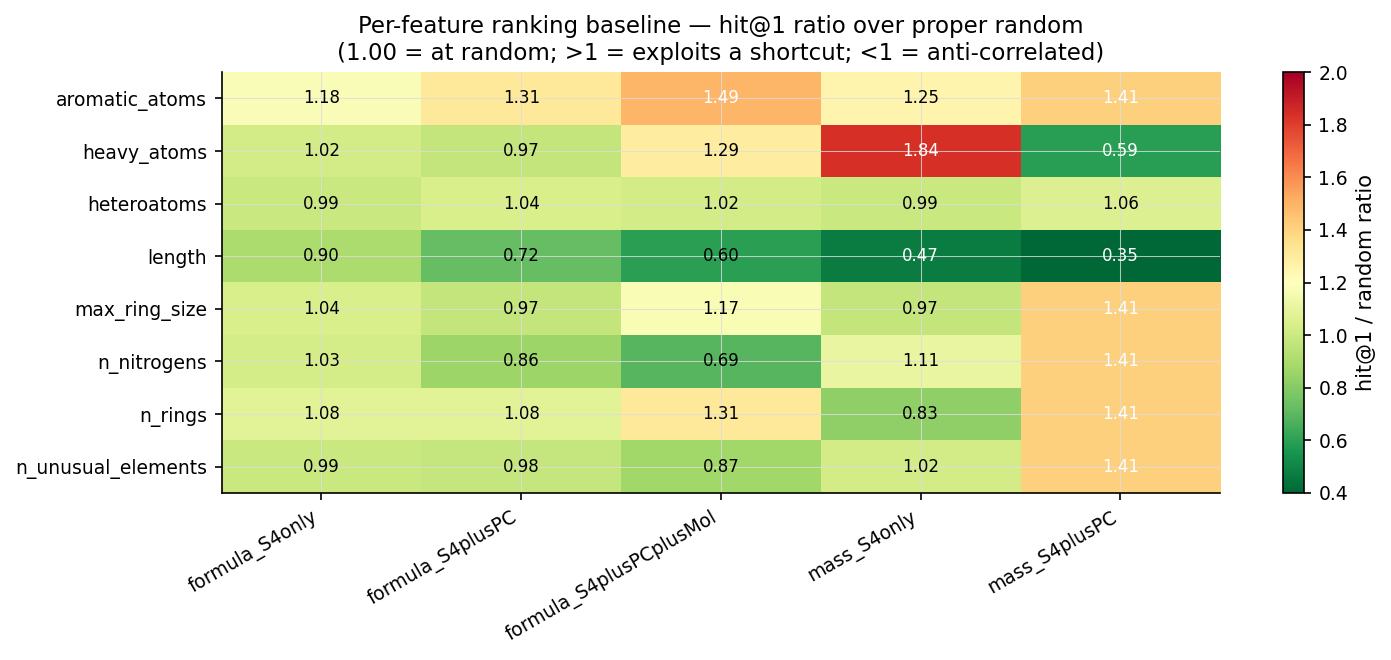

In [7]:
# Heatmap of ratios.
fig, ax = plt.subplots(figsize=(10, 4.5))
mat = piv_ratio[cols].values
im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=0.4, vmax=2.0)
ax.set_xticks(np.arange(len(cols))); ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticks(np.arange(len(piv_ratio.index))); ax.set_yticklabels(piv_ratio.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(mat[i, j] - 1.0) > 0.4 else 'black')
fig.colorbar(im, ax=ax, label='hit@1 / random ratio')
ax.set_title('Per-feature ranking baseline — hit@1 ratio over proper random\n(1.00 = at random; >1 = exploits a shortcut; <1 = anti-correlated)')
fig.tight_layout()
_save(fig, 'per_feature_hit1_ratio_heatmap')
plt.show()

In [8]:
# Distribution comparison: queries vs S4 candidate pool (final, formula).
# Use the S4plusPCplusMol-formula diag.
with (OUT / 'diagnose_residual_formula_nostereo.pkl').open('rb') as f:
    obj_f = pickle.load(f)
df_dist_f = obj_f['dist']
print('=== Distribution: MSG test queries vs S4+PC+Mol formula pool ===')
display(df_dist_f.round(3))

=== Distribution: MSG test queries vs S4+PC+Mol formula pool ===


,feature,GT mean,GT median,GT p10,GT p90,POOL mean,POOL median,POOL p10,POOL p90,Δ mean (GT-POOL)
0,length,58.379,54.0,39.0,86.0,45.212,43.0,30.0,61.0,13.167
1,heavy_atoms,33.369,31.0,23.0,48.0,26.560,26.0,18.0,35.0,6.810
2,n_rings,3.993,4.0,2.0,6.0,3.220,3.0,2.0,5.0,0.773
3,aromatic_atoms,13.538,15.0,0.0,22.0,11.263,12.0,0.0,18.0,2.274
4,heteroatoms,9.102,8.0,6.0,14.0,6.533,6.0,4.0,9.0,2.570
5,n_unusual_elements,0.002,0.0,0.0,0.0,0.001,0.0,0.0,0.0,0.001
6,max_ring_size,6.520,6.0,6.0,7.0,6.085,6.0,6.0,7.0,0.436
7,n_nitrogens,3.437,3.0,0.0,6.0,2.122,2.0,0.0,5.0,1.315


## 4 — Interpretation (revised)

**1. Stereo asymmetry was the dominant spurious shortcut.** After
stripping stereo from both queries and candidates:
- Chirality nostereo numbers are at random (Roman called this out
  correctly — my earlier '1.03% formula = real signal' was wrong because
  I compared against `1/1024` instead of `mean(1/N_i)`).

**2. Single-feature baselines on the corrected data are mostly random.**
The largest shortcut is `aromatic_atoms` count, at ~1.4–1.5× random. This
is a real but modest spurious signal that survives all augmentation steps.

**3. Augmentation helps fix some shortcuts.** Most striking: `heavy_atoms`
ratio for mass dropped from **1.84× (S4-only) → 0.59× (S4+PC)**. PubChem
candidates fill in mass-similar molecules with appropriate sizes, removing
the size-based shortcut that pure-S4 mass candidates had.

**4. ChemBERTa mass at 5.6× random is the remaining signal that's NOT
explained by any single feature** (max single-feature ratio is 1.41×).
ChemBERTa must combine multiple weak features or pick up token-sequence
patterns. Worth investigating further (e.g., n-gram frequencies, specific
substructure tokens) but already much smaller than the original shortcut.

**5. ChemBERTa formula at 1.10× random is essentially random** — the
augmentation steps were enough to make the formula candidates look
in-distribution to ChemBERTa.

**Honest caveat on what I got wrong earlier:**
- I cited 0.098% (1/1024) as the random baseline. It's actually `mean(1/N_i)`
  per query, which is **1.35% for formula final**, **0.28% for mass final**.
  Most spectrum-free baselines on the corrected data are at or just above
  this; only ChemBERTa mass stands clearly above it.
- I had a tie-breaking bug in the original chirality eval that inflated
  the stereo-formula number from 22% → 92% (fixed in
  `eval_chirality_baseline.py`).